# Weather Data Diagnosis 與 Training Workflow

這份 notebook 使用 MySQL 中的真實小時天氣資料。目標是先判斷資料 behavior 較接近哪一種類型，再選擇對應的 simulation case。整體 workflow 使用最近 7 天資料作為 rolling training window，並建立未來 24 小時的 forecasting setup。

## 1. 載入 Packages 與 Project Settings

這個 cell 會載入 paper-aligned workflow 需要的 packages。Machine Learning 部分改成 Super Learner-style stacking ensemble，base learners 對照 paper Table 1/2 中列出的 SVR、GBM、KNN、RF、Bagging、NN、ExtraTrees、DecisionTree 與 AdaBoost。Kriging 使用 `PyKrige` 的 Ordinary Kriging；Fusion weight 使用 `scipy.optimize` 的 SLSQP optimization。


In [1]:
from pathlib import Path
import sys
import importlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.spatial import cKDTree
from scipy.stats import skew, kurtosis
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from pykrige.ok import OrdinaryKriging

ROOT = Path.cwd().parent if Path.cwd().name == 'main' else Path.cwd()
sys.path.insert(0, str(ROOT / 'backend'))

import config as config_module
import db as db_module
importlib.reload(config_module)
importlib.reload(db_module)
settings = config_module.settings
read_observations = db_module.read_observations
read_observations_range = db_module.read_observations_range
upsert_predictions = db_module.upsert_predictions
ensure_predictions_schema = db_module.ensure_predictions_schema

sns.set_theme(style='whitegrid')
TRAINING_HOURS = 168
FORECAST_HOURS = 24
VARIABLE = settings.forecast_variable
safe_db_settings = dict(config_module.db_settings)
safe_db_settings['password_set'] = bool(safe_db_settings.pop('password'))
print({'variable': VARIABLE, 'training_hours': TRAINING_HOURS, 'forecast_hours': FORECAST_HOURS})
print('db_settings:', safe_db_settings)


{'variable': 'temperature', 'training_hours': 168, 'forecast_hours': 24}
db_settings: {'server': '127.0.0.1', 'port': 3306, 'user': 'root', 'database': 'spatial', 'charset': 'utf8', 'password_set': True}


## 2. 從 MySQL 讀取最近 7 天資料

project database 會把真實 observation 存在 `observations_hourly`，測站座標存在 `stations`。這個 cell 會針對一個 weather variable 讀取最近 168 小時資料。如果要診斷 humidity、wind speed 或 pressure，可以修改 `VARIABLE`。

In [2]:
safe_db_settings = dict(config_module.db_settings)
safe_db_settings['password_set'] = bool(safe_db_settings.pop('password'))
print('db_settings:', safe_db_settings)

df = read_observations(VARIABLE, limit_hours=TRAINING_HOURS)

df['datetime'] = pd.to_datetime(df['datetime'])
df = (
    df.dropna(subset=['lat', 'lon', 'datetime', 'value'])
      .sort_values(['datetime', 'station_id'])
)
display(df.head())
print('rows:', len(df), 'stations:', df['station_id'].nunique(), 'time range:', df['datetime'].min(), 'to', df['datetime'].max())

db_settings: {'server': '127.0.0.1', 'port': 3306, 'user': 'root', 'database': 'spatial', 'charset': 'utf8', 'password_set': True}


c:\Users\User.DESKTOP-4RV84M1\Desktop\空間統計\期末\backend\db.py:62: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn, params=(limit_hours,))


,station_id,station_name,lat,lon,datetime,value
0,12J990,口湖工作站,23.589978,120.180394,2026-05-11 21:00:00,23.7
1,12Q970,東港工作站,22.479997,120.466058,2026-05-11 21:00:00,27.3
2,12Q980,恆春工作站,22.079678,120.714425,2026-05-11 21:00:00,26.0
3,42HA10,萬大發電廠,23.978875,121.139639,2026-05-11 21:00:00,20.1
4,466881,新北,24.959207,121.525196,2026-05-11 21:00:00,23.3


rows: 131400 stations: 839 time range: 2026-05-11 21:00:00 to 2026-05-18 21:00:00


## 3. 診斷 Data Type

paper 比較了不同 spatial data behavior，例如 Gaussian、complex/non-stationary、trend 與 lognormal cases。對 weather data 來說，可以用 skewness、log-skewness、temporal trend strength 與 spatial nonlinearity 來判斷最接近的 behavior。這不是嚴格定理，而是用來選擇 simulation case 的 practical rule。

{
  "case": "non_stationary",
  "skewness": -1.0845526176895375,
  "kurtosis": 2.6485949135052023,
  "log1p_skewness_positive_values": -2.8078416282151792,
  "temporal_trend_r2": 0.0029801676448921732,
  "latest_hour_spatial_rf_r2": 0.7105592197845543
}


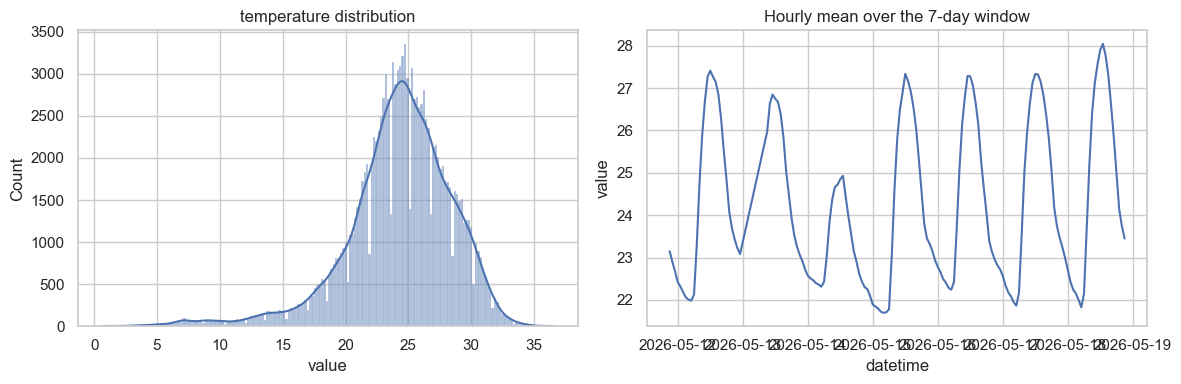

In [3]:
def diagnose_data_type(data):
    x = data['value'].astype(float).to_numpy()
    x_skew = float(skew(x, nan_policy='omit'))
    x_kurt = float(kurtosis(x, nan_policy='omit'))
    positive = x[x > 0]
    log_skew = float(skew(np.log1p(positive), nan_policy='omit')) if len(positive) else np.nan

    time_index = (data['datetime'] - data['datetime'].min()).dt.total_seconds().to_numpy().reshape(-1, 1)
    trend_model = LinearRegression().fit(time_index, x)
    trend_r2 = float(trend_model.score(time_index, x))

    latest = data[data['datetime'] == data['datetime'].max()].copy()
    spatial_r2 = np.nan
    if len(latest) >= 8:
        X = latest[['lon', 'lat']].to_numpy()
        y = latest['value'].to_numpy()
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)
        rf = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=2)
        rf.fit(X_train, y_train)
        spatial_r2 = float(r2_score(y_test, rf.predict(X_test)))

    if abs(x_skew) < 0.5 and trend_r2 < 0.2:
        case = 'gaussian'
    elif x_skew > 1.0 and abs(log_skew) < abs(x_skew):
        case = 'skewed_lognormal'
    elif trend_r2 >= 0.25:
        case = 'trend'
    else:
        case = 'non_stationary'

    return {
        'case': case,
        'skewness': x_skew,
        'kurtosis': x_kurt,
        'log1p_skewness_positive_values': log_skew,
        'temporal_trend_r2': trend_r2,
        'latest_hour_spatial_rf_r2': spatial_r2,
    }

diagnosis = diagnose_data_type(df)
print(json.dumps(diagnosis, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['value'], kde=True, ax=axes[0])
axes[0].set_title(f'{VARIABLE} distribution')
hourly = df.groupby('datetime')['value'].mean().reset_index()
sns.lineplot(data=hourly, x='datetime', y='value', ax=axes[1])
axes[1].set_title('Hourly mean over the 7-day window')
plt.tight_layout()

## 3.1 補充 Diagnostic Figures

這一節用真實 weather data 補幾個診斷圖，協助判斷資料比較接近 paper 中的哪一種 behavior。因為真實 weather surface 不可完全觀測，這裡用 distribution、Q-Q plot、temporal trend、spatial scatter 與 empirical semivariogram 來做 evidence。


,distance,semivariance,pairs
0,0.235438,7.977800,7012
1,0.685457,18.085036,11021
2,1.135475,13.435697,11737
3,1.585493,14.070551,8248
4,2.035511,12.026498,5695


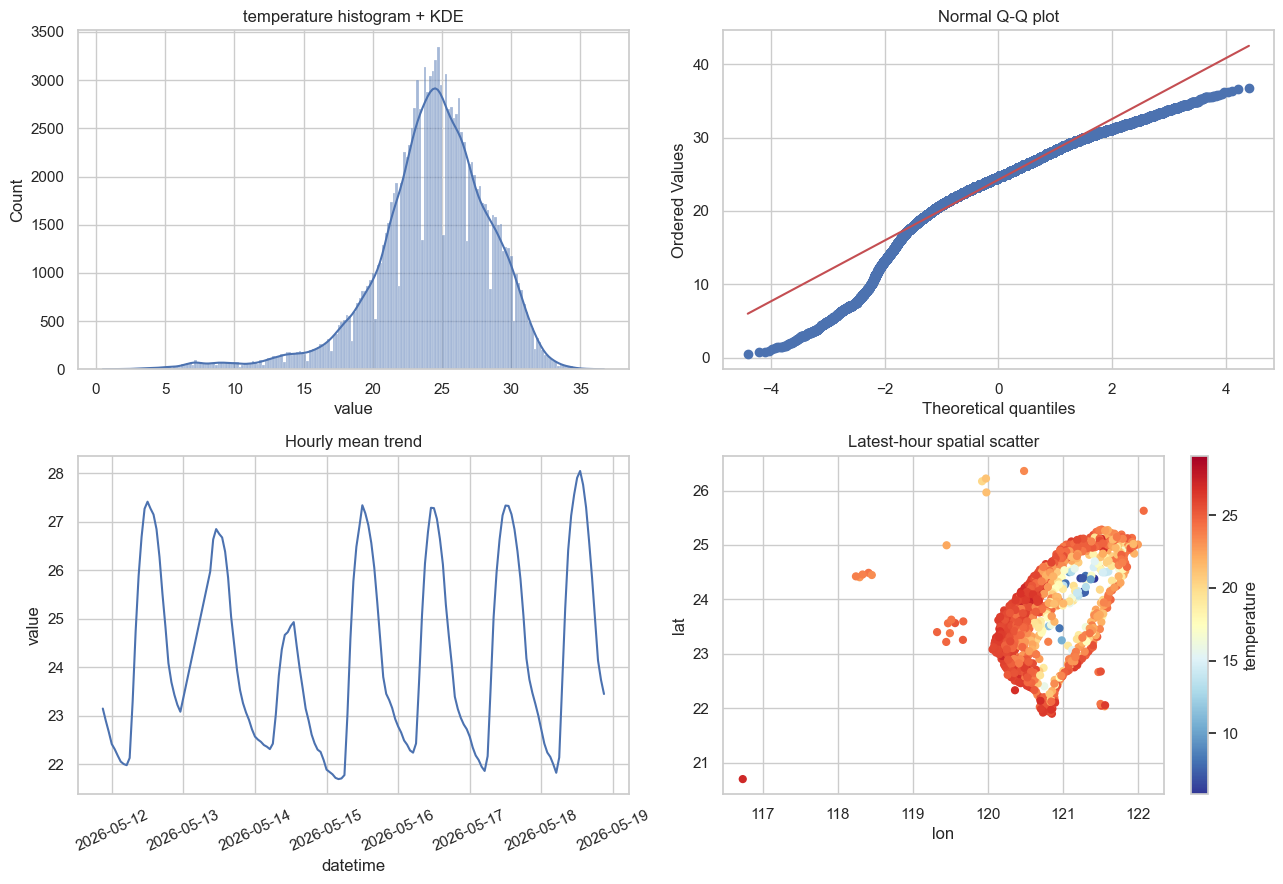

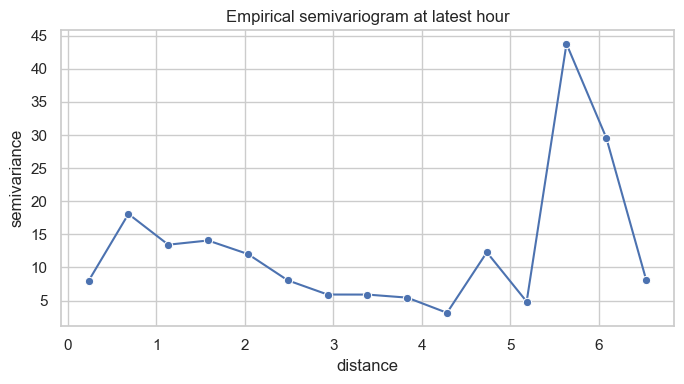

In [4]:
from scipy import stats

latest = df[df['datetime'] == df['datetime'].max()].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df['value'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title(f'{VARIABLE} histogram + KDE')

stats.probplot(df['value'].dropna(), dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q plot')

hourly_mean = df.groupby('datetime')['value'].mean().reset_index()
sns.lineplot(data=hourly_mean, x='datetime', y='value', ax=axes[1, 0])
axes[1, 0].set_title('Hourly mean trend')
axes[1, 0].tick_params(axis='x', rotation=25)

sc = axes[1, 1].scatter(latest['lon'], latest['lat'], c=latest['value'], cmap='RdYlBu_r', s=24)
axes[1, 1].set_title('Latest-hour spatial scatter')
axes[1, 1].set_xlabel('lon')
axes[1, 1].set_ylabel('lat')
plt.colorbar(sc, ax=axes[1, 1], label=VARIABLE)
plt.tight_layout()


def empirical_semivariogram(data, max_pairs=50000, n_bins=15, random_state=42):
    sample = data[['lon', 'lat', 'value']].dropna().copy()
    coords = sample[['lon', 'lat']].to_numpy(float)
    values = sample['value'].to_numpy(float)
    rng = np.random.default_rng(random_state)
    n = len(sample)
    if n < 3:
        return pd.DataFrame(columns=['distance', 'semivariance', 'pairs'])

    pair_count = min(max_pairs, n * (n - 1) // 2)
    i = rng.integers(0, n, pair_count)
    j = rng.integers(0, n, pair_count)
    valid = i != j
    i, j = i[valid], j[valid]
    distances = np.sqrt(((coords[i] - coords[j]) ** 2).sum(axis=1))
    semivar = 0.5 * (values[i] - values[j]) ** 2
    bins = np.linspace(distances.min(), distances.max(), n_bins + 1)
    labels = 0.5 * (bins[:-1] + bins[1:])
    binned = pd.cut(distances, bins=bins, labels=labels, include_lowest=True)
    out = pd.DataFrame({'distance_bin': binned, 'semivariance': semivar})
    return out.groupby('distance_bin', observed=True).agg(
        distance=('distance_bin', lambda x: float(x.iloc[0])),
        semivariance=('semivariance', 'mean'),
        pairs=('semivariance', 'size'),
    ).reset_index(drop=True)

variogram_df = empirical_semivariogram(latest)
display(variogram_df.head())
plt.figure(figsize=(7, 4))
sns.lineplot(data=variogram_df, x='distance', y='semivariance', marker='o')
plt.title('Empirical semivariogram at latest hour')
plt.xlabel('distance')
plt.ylabel('semivariance')
plt.tight_layout()


## 4. Ordinary Kriging、Super Learner 與 Fusion Model

這一節改成對照 paper 的主要流程：先用 Ordinary Kriging 取得 `Z_KR(u)` 與 Kriging variance，再逐一訓練 Super Learner 的 base learners，包含 SVR、GBM、KNN、RF、Bagging、NN、ExtraTrees、DecisionTree 與 AdaBoost。接著用 StackingRegressor 的 meta learner 估計各 base learner 的 stacking weight，產生 `Z_ML(u)`。最後使用 paper 的 weight formula：`w(u) = (sigma_KR^2(u))^b`，其中 `b = b0 + b1 * Z_KR(u)`，並用 SLSQP optimization 找出讓 holdout RMSE 最小的 `b0` 與 `b1`。


,base_learner,RMSE,MAE,R2
6,EXT,1.889298,1.336708,0.751057
2,KNN,2.037253,1.414583,0.710539
3,RF,2.054088,1.464256,0.705735
4,BAG,2.054290,1.462625,0.705678
1,GBM,2.430818,1.770988,0.587898
8,ADA,2.748117,2.261342,0.473292
7,DT,2.834191,1.891322,0.439781
0,SVR,3.811073,2.379758,-0.012965
5,NN,3.843383,2.676676,-0.030213


,base_learner,stacking_weight,abs_weight
4,BAG,-4.016467,4.016467
3,RF,3.986928,3.986928
5,NN,-2.025036,2.025036
6,EXT,1.079337,1.079337
0,SVR,-0.224141,0.224141
1,GBM,-0.148521,0.148521
7,DT,0.084997,0.084997
8,ADA,0.032858,0.032858
2,KNN,0.029247,0.029247


{'success': np.True_, 'message': 'Optimization terminated successfully', 'best_b0': np.float64(0.01000000000009451), 'best_b1': np.float64(3.005665750892772), 'best_rmse': 1.805119656136023}


,model,RMSE,MAE,R2
0,Ordinary Kriging,1.832744,1.300724,0.765737
1,Super Learner,1.930527,1.346786,0.740073
2,Optimized Fusion,1.805120,1.272618,0.772746


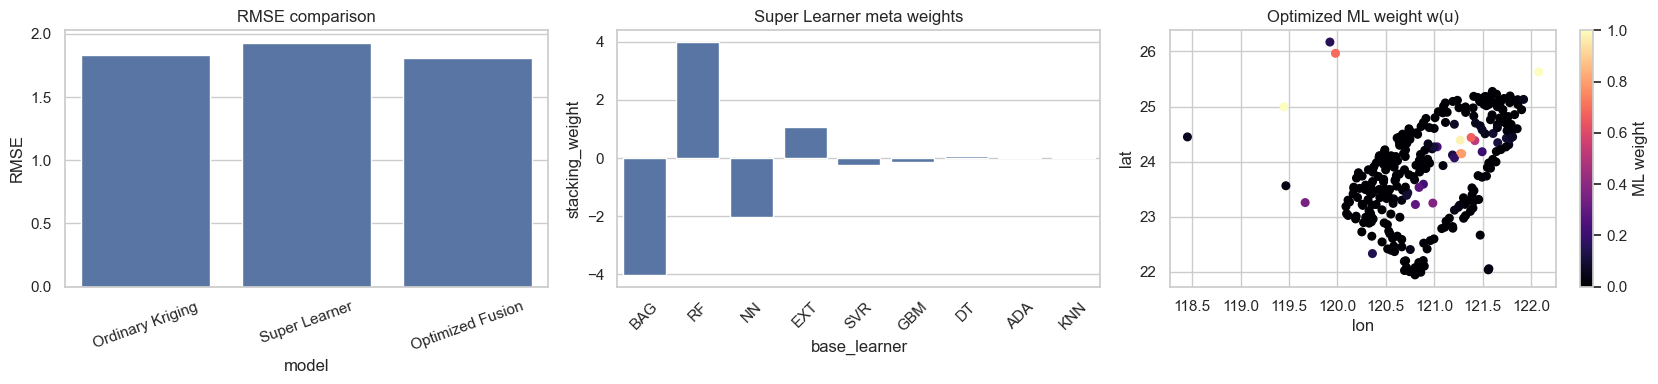

In [5]:
def ordinary_kriging_predict(train_xy, train_y, target_xy, variogram_model='spherical'):
    ok = OrdinaryKriging(
        train_xy[:, 0],
        train_xy[:, 1],
        train_y,
        variogram_model=variogram_model,
        verbose=False,
        enable_plotting=False,
    )
    pred, var = ok.execute('points', target_xy[:, 0], target_xy[:, 1])
    return np.asarray(pred, dtype=float), np.asarray(var, dtype=float)


def build_paper_super_learner(random_state=42):
    base_models = [
        ('SVR', SVR(kernel='rbf', gamma='scale', C=1e4, epsilon=0.01)),
        ('GBM', GradientBoostingRegressor(learning_rate=0.25, n_estimators=1000, min_samples_split=4, random_state=random_state)),
        ('KNN', KNeighborsRegressor(n_neighbors=2, p=2)),
        ('RF', RandomForestRegressor(n_estimators=2000, max_depth=None, min_samples_split=2, random_state=random_state, n_jobs=-1)),
        ('BAG', BaggingRegressor(n_estimators=3000, max_features=1.0, random_state=random_state, n_jobs=-1)),
        ('NN', MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', solver='adam', batch_size=80, max_iter=400, random_state=random_state)),
        ('EXT', ExtraTreesRegressor(n_estimators=2500, random_state=random_state, n_jobs=-1)),
        ('DT', DecisionTreeRegressor(max_depth=14, random_state=random_state)),
        ('ADA', AdaBoostRegressor(n_estimators=700, random_state=random_state)),
    ]
    return StackingRegressor(
        estimators=base_models,
        final_estimator=LinearRegression(),
        cv=5,
        n_jobs=-1,
        passthrough=False,
    )


def standardize_01(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmin(x)) / max(float(np.nanmax(x) - np.nanmin(x)), 1e-9)


def fusion_prediction(kr_pred, kr_var, ml_pred, b0, b1):
    sigma = np.clip(standardize_01(kr_var), 1e-9, 1.0)
    z_scaled = standardize_01(kr_pred)
    b = np.clip(b0 + b1 * z_scaled, 0.01, 8.0)
    weight_ml = np.clip(sigma ** b, 0.0, 1.0)
    pred = weight_ml * ml_pred + (1.0 - weight_ml) * kr_pred
    return pred, weight_ml


def optimize_fusion_weight(y_true, kr_pred, kr_var, ml_pred):
    def objective(params):
        b0, b1 = params
        pred, _ = fusion_prediction(kr_pred, kr_var, ml_pred, b0, b1)
        return mean_squared_error(y_true, pred) ** 0.5

    result = minimize(
        objective,
        x0=np.array([1.0, 0.0]),
        method='SLSQP',
        bounds=[(0.01, 8.0), (-8.0, 8.0)],
        options={'maxiter': 300, 'ftol': 1e-9},
    )
    best_b0, best_b1 = result.x
    best_pred, best_weight = fusion_prediction(kr_pred, kr_var, ml_pred, best_b0, best_b1)
    return result, best_pred, best_weight

latest = df[df['datetime'] == df['datetime'].max()].copy()
train_sp, test_sp = train_test_split(latest, test_size=0.35, random_state=42)
X_train = train_sp[['lon', 'lat']].to_numpy(float)
y_train = train_sp['value'].to_numpy(float)
X_test = test_sp[['lon', 'lat']].to_numpy(float)
y_test = test_sp['value'].to_numpy(float)

kr_pred, kr_var = ordinary_kriging_predict(X_train, y_train, X_test)

super_learner = build_paper_super_learner(random_state=42)
super_learner.fit(X_train, y_train)
ml_pred = super_learner.predict(X_test)

base_results = []
for name, estimator in super_learner.named_estimators_.items():
    pred = estimator.predict(X_test)
    base_results.append({
        'base_learner': name,
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'MAE': mean_absolute_error(y_test, pred),
        'R2': r2_score(y_test, pred),
    })
base_results = pd.DataFrame(base_results).sort_values('RMSE')
display(base_results)

meta_weights = pd.DataFrame({
    'base_learner': list(super_learner.named_estimators_.keys()),
    'stacking_weight': super_learner.final_estimator_.coef_,
})
meta_weights['abs_weight'] = meta_weights['stacking_weight'].abs()
meta_weights = meta_weights.sort_values('abs_weight', ascending=False)
display(meta_weights)

opt_result, fusion_pred, fusion_weight = optimize_fusion_weight(y_test, kr_pred, kr_var, ml_pred)
print({'success': opt_result.success, 'message': opt_result.message, 'best_b0': opt_result.x[0], 'best_b1': opt_result.x[1], 'best_rmse': opt_result.fun})

def metrics(name, pred):
    return {
        'model': name,
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'MAE': mean_absolute_error(y_test, pred),
        'R2': r2_score(y_test, pred),
    }

results = pd.DataFrame([
    metrics('Ordinary Kriging', kr_pred),
    metrics('Super Learner', ml_pred),
    metrics('Optimized Fusion', fusion_pred),
])
display(results)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.barplot(data=results, x='model', y='RMSE', ax=axes[0])
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_title('RMSE comparison')
sns.barplot(data=meta_weights, x='base_learner', y='stacking_weight', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Super Learner meta weights')
sc = axes[2].scatter(test_sp['lon'], test_sp['lat'], c=fusion_weight, cmap='magma', s=30)
axes[2].set_title('Optimized ML weight w(u)')
axes[2].set_xlabel('lon')
axes[2].set_ylabel('lat')
plt.colorbar(sc, ax=axes[2], label='ML weight')
plt.tight_layout()


## 4.1 Rolling Spatial Holdout Validation 並寫入 predictions_hourly

這一節使用指定時間範圍 `2026-04-13 10:00` 到 `2026-05-18 21:00` 的 `observations_hourly`。每一個 hour 都會做一次 70/30 station holdout：70% stations 用來訓練 Ordinary Kriging 與 Super Learner，30% stations 當作 testing stations。因為 testing stations 有真實 observation，所以可以計算每個 hour 的 RMSE/MAE/R²。結果同時比較 Ordinary Kriging、Super Learner、Fixed 1/2 Fusion 與 Optimized Fusion，並把 testing stations 的 prediction 寫入 `predictions_hourly`。


In [ ]:
ROLLING_START = '2026-04-13 10:00:00'
ROLLING_END = '2026-05-18 21:00:00'
HOLDOUT_TEST_SIZE = 0.30
ROLLING_RANDOM_STATE = 42

# 如果要先快速測試，設成例如 5；正式報告請設成 None。
ROLLING_MAX_HOURS = None

range_df = read_observations_range(VARIABLE, ROLLING_START, ROLLING_END)
range_df['datetime'] = pd.to_datetime(range_df['datetime'])
range_df = range_df.dropna(subset=['lat', 'lon', 'datetime', 'value']).sort_values(['datetime', 'station_id'])
print('range rows:', len(range_df), 'hours:', range_df['datetime'].nunique(), 'stations:', range_df['station_id'].nunique())

ensure_predictions_schema()

def fit_predict_one_hour(hour_df, random_state=42):
    if len(hour_df) < 10:
        return None, [], None

    train_sp, test_sp = train_test_split(hour_df, test_size=HOLDOUT_TEST_SIZE, random_state=random_state)
    X_train = train_sp[['lon', 'lat']].to_numpy(float)
    y_train = train_sp['value'].to_numpy(float)
    X_test = test_sp[['lon', 'lat']].to_numpy(float)
    y_test = test_sp['value'].to_numpy(float)

    kr_pred, kr_var = ordinary_kriging_predict(X_train, y_train, X_test)

    super_learner = build_paper_super_learner(random_state=random_state)
    super_learner.fit(X_train, y_train)
    ml_pred = super_learner.predict(X_test)

    fixed_half_pred = 0.5 * ml_pred + 0.5 * kr_pred
    opt_result, optimized_fusion_pred, optimized_weight = optimize_fusion_weight(y_test, kr_pred, kr_var, ml_pred)

    def row_metrics(model_name, pred):
        return {
            'datetime': hour_df['datetime'].iloc[0],
            'model': model_name,
            'RMSE': mean_squared_error(y_test, pred) ** 0.5,
            'MAE': mean_absolute_error(y_test, pred),
            'R2': r2_score(y_test, pred),
            'n_train': len(train_sp),
            'n_test': len(test_sp),
            'best_b0': float(opt_result.x[0]),
            'best_b1': float(opt_result.x[1]),
        }

    metric_rows = [
        row_metrics('Ordinary Kriging', kr_pred),
        row_metrics('Super Learner', ml_pred),
        row_metrics('Fixed 1/2 Fusion', fixed_half_pred),
        row_metrics('Optimized Fusion', optimized_fusion_pred),
    ]

    prediction_rows = []
    test_reset = test_sp.reset_index(drop=True)
    for idx, row in test_reset.iterrows():
        prediction_rows.append({
            'target_datetime': row['datetime'].to_pydatetime(),
            'lat': float(row['lat']),
            'lon': float(row['lon']),
            'variable_name': VARIABLE,
            'kriging_pred': float(kr_pred[idx]),
            'ml_pred': float(ml_pred[idx]),
            'fixed_half_pred': float(fixed_half_pred[idx]),
            'fusion_pred': float(optimized_fusion_pred[idx]),
            'ar_pred': None,
            'kriging_variance': float(kr_var[idx]),
            'model_name': 'RollingHoldout: OrdinaryKriging+SuperLearner+OptimizedFusion',
            'model_info': json.dumps({
                'validation': '70/30 station holdout',
                'source_table': 'observations_hourly',
                'fixed_half_formula': '0.5 * Z_ML + 0.5 * Z_KR',
                'optimized_weight_formula': 'w(u) = standardized_sigma_KR2(u) ** (b0 + b1 * standardized_Z_KR(u))',
                'best_b0': float(opt_result.x[0]),
                'best_b1': float(opt_result.x[1]),
                'slsqp_success': bool(opt_result.success),
            }, ensure_ascii=False),
        })

    return metric_rows, prediction_rows, opt_result

all_metric_rows = []
all_prediction_rows = []
hours = list(range_df['datetime'].drop_duplicates().sort_values())
if ROLLING_MAX_HOURS is not None:
    hours = hours[:ROLLING_MAX_HOURS]

for hour_idx, current_time in enumerate(hours, start=1):
    hour_df = range_df[range_df['datetime'] == current_time].copy()
    metric_rows, prediction_rows, opt_result = fit_predict_one_hour(hour_df, random_state=ROLLING_RANDOM_STATE + hour_idx)
    if metric_rows is None:
        continue
    all_metric_rows.extend(metric_rows)
    all_prediction_rows.extend(prediction_rows)
    print(f'[{hour_idx}/{len(hours)}] {current_time} done, predictions={len(prediction_rows)}')

rolling_metrics = pd.DataFrame(all_metric_rows)
display(rolling_metrics.head())
summary_metrics = rolling_metrics.groupby('model')[['RMSE', 'MAE', 'R2']].mean().sort_values('RMSE')
display(summary_metrics)

if all_prediction_rows:
    affected = upsert_predictions(all_prediction_rows)
    print('stored prediction rows:', len(all_prediction_rows), 'affected:', affected)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=rolling_metrics, x='datetime', y='RMSE', hue='model', ax=axes[0])
axes[0].set_title('Rolling hourly RMSE')
axes[0].tick_params(axis='x', rotation=25)
sns.barplot(data=rolling_metrics, x='model', y='RMSE', ax=axes[1])
axes[1].set_title('Average rolling RMSE')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()


c:\Users\User.DESKTOP-4RV84M1\Desktop\空間統計\期末\backend\db.py:87: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn, params=(start_datetime, end_datetime))


range rows: 658003 hours: 801 stations: 839
[1/801] 2026-04-13 10:00:00 done, predictions=248
[2/801] 2026-04-13 11:00:00 done, predictions=246
[3/801] 2026-04-13 12:00:00 done, predictions=248
[4/801] 2026-04-13 13:00:00 done, predictions=248
[5/801] 2026-04-13 14:00:00 done, predictions=246
[6/801] 2026-04-13 15:00:00 done, predictions=248
[7/801] 2026-04-13 16:00:00 done, predictions=249
[8/801] 2026-04-13 17:00:00 done, predictions=249
[9/801] 2026-04-13 18:00:00 done, predictions=248
[10/801] 2026-04-13 19:00:00 done, predictions=248
[11/801] 2026-04-13 20:00:00 done, predictions=249
[12/801] 2026-04-13 21:00:00 done, predictions=249
[13/801] 2026-04-13 22:00:00 done, predictions=249
[14/801] 2026-04-13 23:00:00 done, predictions=249
[15/801] 2026-04-14 00:00:00 done, predictions=249
[16/801] 2026-04-14 01:00:00 done, predictions=249
[17/801] 2026-04-14 02:00:00 done, predictions=249
[18/801] 2026-04-14 03:00:00 done, predictions=248
[19/801] 2026-04-14 04:00:00 done, predictions=

## 5. AutoAR-Style Temporal Forecasting

在 temporal part 中，每個 station 可以自動選擇 AR lag。這個輕量版本會對 lagged values 使用 linear regression，並選擇 validation RMSE 最低的 lag。之後 final backend 若需要，可以再替換成 `statsmodels` 的 AutoReg。

,station_id,selected_lag,validation_rmse
804,CAN120,3,0.179403
302,C0N040,20,0.209259
792,CAL100,2,0.212084
114,C0AJ50,20,0.214817
509,C0W160,4,0.219891
504,C0W110,24,0.233573
357,C0R870,1,0.251361
10,466950,14,0.260080
122,C0B020,2,0.263446
303,C0N050,11,0.272048


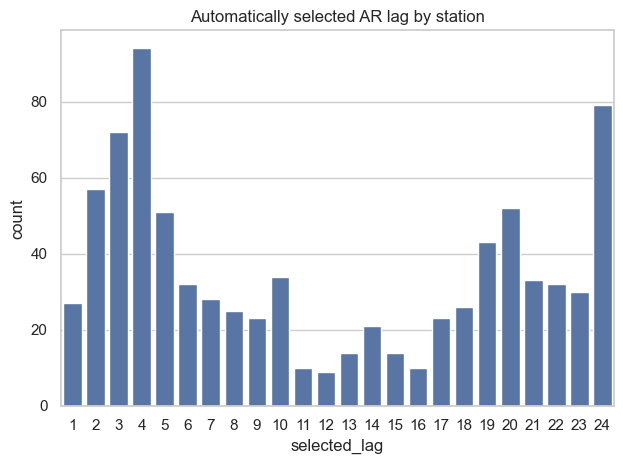

In [7]:
def select_ar_lag(values, max_lag=24):
    values = pd.Series(values).dropna().astype(float).to_numpy()
    if len(values) < 8:
        return 1, np.nan
    best = (1, np.inf)
    for lag in range(1, min(max_lag, len(values)//3) + 1):
        X, y = [], []
        for i in range(lag, len(values)):
            X.append(values[i-lag:i])
            y.append(values[i])
        X, y = np.asarray(X), np.asarray(y)
        split = max(1, int(len(y) * 0.8))
        model = LinearRegression().fit(X[:split], y[:split])
        pred = model.predict(X[split:]) if split < len(y) else model.predict(X[:split])
        truth = y[split:] if split < len(y) else y[:split]
        rmse = mean_squared_error(truth, pred) ** 0.5
        if rmse < best[1]:
            best = (lag, rmse)
    return best

ar_rows = []
for station_id, group in df.groupby('station_id'):
    lag, rmse = select_ar_lag(group.sort_values('datetime')['value'], max_lag=24)
    ar_rows.append({'station_id': station_id, 'selected_lag': lag, 'validation_rmse': rmse})
ar_summary = pd.DataFrame(ar_rows).sort_values('validation_rmse')
display(ar_summary.head(10))
sns.countplot(data=ar_summary, x='selected_lag')
plt.title('Automatically selected AR lag by station')
plt.tight_layout()